# Question 3 : GMM Implementation

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import hashlib

# For debugging purposes, not used in final implementation
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal
import warnings
warnings.filterwarnings("ignore")

In [154]:
def _add_username(username) -> None:
    plt.text(0.95, 0.95, username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

def print_separator() -> None:
    print("\n" + "="*50 + "\n")

In [155]:
username = "siddarth.g+"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
print("Seed value : ", seed)
print_separator()

global_flag = True  # Set to True to use custom GMM implementation

Seed value :  2321765581




In [156]:
class GMM:
    """
    Gaussian Mixture Model implementation using Expectation-Maximization algorithm
    """
    
    def __init__(self, k, max_iters=100, tol=1e-4, random_state=42):
        """
        Initialize Gaussian Mixture Model
        
        Parameters:
        k (int): Number of clusters/components
        max_iters (int): Maximum number of iterations for EM algorithm
        tol (float): Convergence tolerance
        random_state (int): Random seed for reproducibility
        """
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        
    def fit(self, X):
        """
        Implements the Expectation-Maximization (EM) algorithm to determine optimal parameters
        
        Parameters:
        X (array-like): Training data of shape (n_samples, n_features)
        
        Returns:
        self: Returns the instance itself
        """
        np.random.seed(self.random_state)
        self.X = X
        self.n_samples, self.n_features = X.shape
        
        # Initialize parameters
        self._initialize_parameters()

        # Store log likelihood history for convergence monitoring
        self.log_likelihood_history = []
        
        for iteration in range(self.max_iters):
            # E-step: Calculate responsibilities (membership probabilities)
            responsibilities = self._expectation_step()
            
            # M-step: Update parameters
            self._maximization_step(responsibilities)

            # Calculate current log likelihood
            current_log_likelihood = self.getLogLikelihood()
            self.log_likelihood_history.append(current_log_likelihood)

            # Check for convergence
            if iteration > 0:
                if abs(self.log_likelihood_history[-1] - self.log_likelihood_history[-2]) < self.tol:
                    print(f"Converged after {iteration + 1} iterations")
                    break
        
        return self
    
    def _initialize_parameters(self):
        """
        Initialize GMM parameters (weights, means, covariances)
        """
        # Initialize mixing coefficients (weights) uniformly
        self.weights = np.ones(self.k) / self.k
        
        # Initialize means by sampling k distinct data points for better stability
        idx = np.random.choice(self.n_samples, self.k, replace=False)
        self.means = self.X[idx].astype(float).copy()
        
        # Initialize covariances using the overall data covariance with small regularization
        data_cov = np.cov(self.X, rowvar=False)
        if data_cov.ndim == 0:
            data_cov = np.eye(self.n_features)
        reg = 1e-6
        base_cov = data_cov + np.eye(self.n_features) * reg
        self.covariances = np.array([base_cov.copy() for _ in range(self.k)])
    
    def _expectation_step(self):
        """
        E-step: Calculate responsibilities (posterior probabilities)
        
        Returns:
        array: Responsibility matrix of shape (n_samples, k)
        """
        responsibilities = np.zeros((self.n_samples, self.k))
        
        for k in range(self.k):
            # Calculate probability density for each component
            try:
                responsibilities[:, k] = self.weights[k] * self._multivariate_normal(self.X, self.means[k], self.covariances[k])
            except np.linalg.LinAlgError:
                # Handle singular covariance matrix by adding jitter
                self.covariances[k] += np.eye(self.n_features) * 1e-6
                responsibilities[:, k] = self.weights[k] * self._multivariate_normal(self.X, self.means[k], self.covariances[k])
        
        # Normalize responsibilities with epsilon to avoid division by zero
        responsibilities_sum = responsibilities.sum(axis=1, keepdims=True)
        responsibilities_sum = np.clip(responsibilities_sum, 1e-300, None)
        responsibilities /= responsibilities_sum
        
        return responsibilities

    # Custom implementation of multivariate normal PDF
    def _multivariate_normal(self, x, mean, cov):
        """
        Compute the probability density function of a multivariate normal distribution.
        
        Parameters:
        x (array-like): Data points of shape (n_samples, n_features) or (n_features,)
        mean (array-like): Mean vector of shape (n_features,)
        cov (array-like): Covariance matrix of shape (n_features, n_features)
        
        Returns:
        array: Probability densities for each data point
        """
        n = mean.shape[0]
        
        # Handle both single point and multiple points
        x = np.atleast_2d(x)
        if x.shape[0] == 1 and x.shape[1] != n:
            x = x.T  # Transpose if it's a single point passed as row vector
        
        diff = x - mean
        
        try:
            inv_cov = np.linalg.inv(cov)
            det_cov = np.linalg.det(cov)
        except np.linalg.LinAlgError:
            # In case of singular matrix, add small regularization
            cov = cov + np.eye(n) * 1e-6
            inv_cov = np.linalg.inv(cov)
            det_cov = np.linalg.det(cov)
        
        # Ensure determinant is positive
        if det_cov <= 0:
            det_cov = 1e-10
        
        norm_const = 1.0 / np.sqrt((2 * np.pi) ** n * det_cov)
        
        # Calculate the quadratic form for each data point
        if diff.ndim == 1:
            # Single point case
            exponent = -0.5 * diff @ inv_cov @ diff.T
        else:
            # Multiple points case
            exponents = -0.5 * np.sum((diff @ inv_cov) * diff, axis=1)
        
        return norm_const * np.exp(exponents)    
    
    def _maximization_step(self, responsibilities):
        """
        M-step: Update parameters based on responsibilities
        
        Parameters:
        responsibilities (array): Responsibility matrix from E-step
        """
        # Calculate effective number of points assigned to each component
        Nk = responsibilities.sum(axis=0)
        
        # Update mixing coefficients (weights)
        total = Nk.sum()
        if total <= 0:
            # Fallback to uniform if something went numerically wrong
            self.weights = np.ones(self.k) / self.k
        else:
            self.weights = Nk / total
        
        # Update means
        for k in range(self.k):
            if Nk[k] > 0:
                self.means[k] = np.sum(responsibilities[:, k:k+1] * self.X, axis=0) / Nk[k]
        
        # Update covariances with small diagonal regularization
        for k in range(self.k):
            if Nk[k] > 0:
                diff = self.X - self.means[k]
                self.covariances[k] = np.sum(responsibilities[:, k:k+1, np.newaxis] * (diff[:, :, np.newaxis] @ diff[:, np.newaxis, :]),
                                             axis=0) / Nk[k]
                # Regularize to prevent singular matrices
                self.covariances[k] += np.eye(self.n_features) * 1e-6
    
    def getMembership(self):
        """
        Returns the membership values for each sample in the dataset
        
        Returns:
        array: Membership probability matrix of shape (n_samples, k)
        """
        return self._expectation_step()
    
    def getLogLikelihood(self):
        """
        Returns the overall log likelihood of the entire dataset under current model parameters
        
        Returns:
            float: Log-likelihood of the data
        """
        eps = 1e-300
        
        # Vectorized computation: calculate all component likelihoods at once
        component_likelihoods = np.zeros((self.n_samples, self.k))
        
        for k in range(self.k):
            try:
                # Calculate PDF for all samples at once for component k
                pdf_vals = self._multivariate_normal(self.X, self.means[k], self.covariances[k])
                component_likelihoods[:, k] = self.weights[k] * pdf_vals
            except np.linalg.LinAlgError:
                # In rare cases, fall back to a tiny value
                component_likelihoods[:, k] = self.weights[k] * 1e-8
        
        # Sum across components to get sample likelihoods, then take log
        sample_likelihoods = np.sum(component_likelihoods, axis=1)
        sample_likelihoods = np.clip(sample_likelihoods, eps, None)  # Vectorized clipping
        log_likelihood = np.sum(np.log(sample_likelihoods))

        return log_likelihood
    
    def drawLikelihood(self):
        """
        Draws the plot of likelihood vs iterations for the number of clusters used
        """
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(self.log_likelihood_history) + 1), self.log_likelihood_history, 
                'b-', linewidth=2, marker='o', markersize=4)
        plt.title(f'Likelihood vs Iterations (k={self.k})', fontsize=14)
        plt.xlabel('Iteration', fontsize=12)
        plt.ylabel('Log-Likelihood', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        _add_username("siddarth.g")
        plt.show()
        
        print(f"Final log likelihood: {self.log_likelihood_history[-1]:.4f}")
        print(f"Converged in {len(self.log_likelihood_history)} iterations")
    
    def predict(self, X):
        """
        Predict cluster assignments for new data points
        
        Parameters:
        X (array-like): Data points to predict
        
        Returns:
        array: Predicted cluster labels
        """
        responsibilities = np.zeros((X.shape[0], self.k))
        
        for k in range(self.k):
            try:
                responsibilities[:, k] = self.weights[k] * self._multivariate_normal(X, self.means[k], self.covariances[k])
            except np.linalg.LinAlgError:
                # Handle singular covariance matrix
                self.covariances[k] += np.eye(self.n_features) * 1e-6
                responsibilities[:, k] = self.weights[k] * self._multivariate_normal(X, self.means[k], self.covariances[k])
        
        # Normalize to get soft assignments then argmax for labels
        denom = responsibilities.sum(axis=1, keepdims=True)
        denom = np.clip(denom, 1e-300, None)
        responsibilities /= denom
        return np.argmax(responsibilities, axis=1)
    
    def getBIC(self):
        """
        Calculate Bayesian Information Criterion
        
        Returns:
        float: BIC score
        """
        n_params = self.k * (self.n_features + 0.5 * self.n_features * (self.n_features + 1)) + (self.k - 1)
        bic = -2 * self.getLogLikelihood() + n_params * np.log(self.n_samples)
        return bic

In [157]:
def load_and_preprocess_data(df : pd.DataFrame, seed : int) -> pd.DataFrame:
    """
    Load and preprocess the customer dataset
    Parameters:
    df (DataFrame): Input dataframe containing the dataset
    seed (int): Random seed for reproducibility
    Returns:
    df (DataFrame): Preprocessed dataframe
    """

    # Display basic information about the dataset
    print("Dataset Info:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nData types:")
    print(df.dtypes)
    print("\nFirst few rows:")
    print(df.head())

    # Check for missing values
    print("\nMissing values:")
    missing_values = df.isnull().sum()
    print(missing_values)

    if missing_values.sum() > 0:
        print("\nHandling missing values...")
        
        # Handle Gender column probabilistically (stratified approach)
        if df['Genre'].isnull().any():
            # Calculate the proportion of each gender in the non-missing data
            gender_proportions = df['Genre'].value_counts(normalize=True)
            
            # Fill missing gender values probabilistically
            missing_gender_count = df['Genre'].isnull().sum()
            if missing_gender_count > 0:
                np.random.seed(seed)  # For reproducibility
                random_genders = np.random.choice(
                    gender_proportions.index, 
                    size=missing_gender_count, 
                    p=gender_proportions.values
                )
                df.loc[df['Genre'].isnull(), 'Genre'] = random_genders
        
        # Fill numerical columns with median values
        numerical_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
        for col in numerical_columns:
            if df[col].isnull().any():
                median_value = df[col].median()
                df[col].fillna(median_value, inplace=True)
                print(f"Filled {col} missing values with median: {median_value}")

    # Box plots to identify outliers
    print("\nPlotting box plots to identify outliers...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Box Plots for Outlier Detection', fontsize=16)

    numerical_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
    colors = ['skyblue', 'lightgreen', 'salmon']

    for i, col in enumerate(numerical_columns):
        axes[i].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.7))
        axes[i].set_title(f'{col} Box Plot')
        axes[i].set_ylabel(col)
        _add_username("siddarth.g")

    plt.tight_layout()
    plt.show()

    # Detect and handle outliers using IQR method
    # print("\nDetecting and handling outliers...")
    # for col in numerical_columns:
    #     Q1 = df[col].quantile(0.25)
    #     Q3 = df[col].quantile(0.75)
    #     IQR = Q3 - Q1
        
    #     # Define outlier bounds
    #     lower_bound = Q1 - 1.5 * IQR
    #     upper_bound = Q3 + 1.5 * IQR
        
    #     # Identify outliers
    #     outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
    #     if len(outliers) > 0:
    #         print(f"\n{col}: Found {len(outliers)} outliers")
    #         print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
            
    #         # Replace outliers with median
    #         median_value = df[col].median()
    #         df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = median_value
    #         print(f"Replaced outliers with median: {median_value}")
    #     else:
    #         print(f"\n{col}: No outliers detected")

    return df

In [158]:
def bic_method(X, max_k=10, max_iters=100, use_custom=True):
    """
    Implement BIC method to find optimal number of clusters
    
    Parameters:
        X (array): Preprocessed data
        max_k (int): Maximum number of clusters to test
        max_iters (int): Maximum number of iterations for EM algorithm
        use_custom (bool): True to use custom GMM, False to use sklearn
    
    Returns:
        tuple: (BIC values list, optimal k)
    """
    bic_values = []
    k_range = range(1, max_k + 1)
    
    print(f"Computing BIC using {'Custom GMM' if use_custom else 'Sklearn GMM'} implementation...")
    for k in k_range:
        print(f"  k={k}...", end=" ")
        
        if use_custom:
            # Use custom GMM implementation
            gmm = GMM(k=k, max_iters=max_iters)
            gmm.fit(X)
            bic = gmm.getBIC()
        else:
            # Use sklearn's GaussianMixture
            gmm = GaussianMixture(n_components=k, random_state=42, max_iter=max_iters)
            gmm.fit(X)
            bic = gmm.bic(X)
        
        bic_values.append(bic)
        print(f"BIC: {bic:.2f}")
    
    # Plot BIC vs k
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, bic_values, 'ro-', linewidth=2, markersize=8)
    plt.title(f'BIC Method for Optimal k ({'Custom' if use_custom else 'Sklearn'} GMM Implementation)', fontsize=14)
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('BIC Score', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(k_range)
    plt.tight_layout()
    _add_username("siddarth.g")
    plt.show()
    
    # Find k with minimum BIC (lower BIC is better)
    optimal_k = k_range[np.argmin(bic_values)]
    
    print(f"\nBIC Method Results:")
    print(f"BIC values: {dict(zip(k_range, [f'{bic:.2f}' for bic in bic_values]))}")
    print(f"Optimal k (minimum BIC): {optimal_k}")
    print(f"Minimum BIC score: {min(bic_values):.4f}")
    print(f"Using {'Custom GMM' if use_custom else 'Sklearn GMM'} implementation")
    
    return bic_values, optimal_k

In [159]:
def silhouette_method_gmm(X, max_k=10, max_iters=50, use_custom=True):
    """
    Implement Silhouette Method for GMM to find optimal number of clusters
    
    Parameters:
        X (array): Preprocessed data
        max_k (int): Maximum number of clusters to test
        max_iters (int): Maximum number of iterations for EM algorithm
        use_custom (bool): True to use custom GMM, False to use sklearn
    
    Returns:
        tuple: (Silhouette scores list, optimal k)
    """
    silhouette_scores = []
    k_range = range(2, max_k + 1)  # Silhouette requires at least 2 clusters
    
    print(f"Computing Silhouette scores using {'Custom GMM' if use_custom else 'Sklearn GMM'} implementation...")
    for k in k_range:
        print(f"  k={k}...", end=" ")
        
        if use_custom:
            # Use custom GMM implementation
            gmm = GMM(k=k, max_iters=max_iters)
            gmm.fit(X)
            labels = gmm.predict(X)
        else:
            # Use sklearn's GaussianMixture
            gmm = GaussianMixture(n_components=k, random_state=42, max_iter=max_iters)
            gmm.fit(X)
            labels = gmm.predict(X)
        
        # Calculate silhouette score
        if len(np.unique(labels)) > 1:  # Need at least 2 clusters
            score = silhouette_score(X, labels)
            silhouette_scores.append(score)
            print(f"Score: {score:.4f}")
        else:
            silhouette_scores.append(0)
            print("Score: 0.0000 (single cluster)")
    
    # Plot silhouette scores vs k
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
    plt.title(f'Silhouette Method for Optimal k ({'Custom' if use_custom else 'Sklearn'} GMM Implementation)', fontsize=14)
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('Average Silhouette Score', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(k_range)
    plt.tight_layout()
    _add_username("siddarth.g")
    plt.show()
    
    # Find k with maximum silhouette score
    optimal_k = k_range[np.argmax(silhouette_scores)]
    
    print(f"\nSilhouette Method Results:")
    print(f"Silhouette scores: {dict(zip(k_range, [f'{score:.4f}' for score in silhouette_scores]))}")
    print(f"Optimal k (maximum silhouette score): {optimal_k}")
    print(f"Maximum silhouette score: {max(silhouette_scores):.4f}")
    print(f"Using {'Custom GMM' if use_custom else 'Sklearn GMM'} implementation")
    
    return silhouette_scores, optimal_k

In [160]:
def combined_optimal_k_method_gmm(X, max_k=10, max_iters=100, use_custom=True):
    """
    Combined BIC and Silhouette Method for GMM to find optimal number of clusters
    Trains each model only once and computes both BIC and silhouette scores
    
    Parameters:
        X (array): Preprocessed data
        max_k (int): Maximum number of clusters to test
        max_iters (int): Maximum number of iterations for EM algorithm
        use_custom (bool): True to use custom GMM, False to use sklearn
    
    Returns:
        tuple: (bic_values, silhouette_scores, bic_k, silhouette_k)
    """
    bic_values = []
    silhouette_scores = []
    k_range_bic = range(1, max_k + 1)
    k_range_silhouette = range(2, max_k + 1)  # Silhouette requires at least 2 clusters
    
    print(f"Computing BIC and Silhouette scores using {'Custom GMM' if use_custom else 'Sklearn GMM'} implementation...")
    print("This combined approach trains each model only once per k value.\n")
    
    for k in k_range_bic:
        print(f"  k={k}...", end=" ")
        
        if use_custom:
            # Use custom GMM implementation
            gmm = GMM(k=k, max_iters=max_iters)
            gmm.fit(X)
            bic = gmm.getBIC()
            labels = gmm.predict(X)
        else:
            # Use sklearn's GaussianMixture
            gmm = GaussianMixture(n_components=k, random_state=42, max_iter=max_iters)
            gmm.fit(X)
            bic = gmm.bic(X)
            labels = gmm.predict(X)
        
        bic_values.append(bic)
        
        # Calculate silhouette score only for k >= 2
        if k >= 2:
            if len(np.unique(labels)) > 1:  # Need at least 2 clusters
                score = silhouette_score(X, labels)
                silhouette_scores.append(score)
                print(f"BIC: {bic:.2f}, Silhouette: {score:.4f}")
            else:
                silhouette_scores.append(0)
                print(f"BIC: {bic:.2f}, Silhouette: 0.0000 (single cluster)")
        else:
            print(f"BIC: {bic:.2f}, Silhouette: N/A (k=1)")
    
    # Plot BIC and Silhouette scores side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # BIC plot
    ax1.plot(k_range_bic, bic_values, 'ro-', linewidth=2, markersize=8)
    ax1.set_title(f'BIC Method for Optimal k ({'Custom' if use_custom else 'Sklearn'} GMM Implementation)', fontsize=14)
    ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax1.set_ylabel('BIC Score', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(k_range_bic)
    
    # Silhouette plot
    ax2.plot(k_range_silhouette, silhouette_scores, 'go-', linewidth=2, markersize=8)
    ax2.set_title(f'Silhouette Method for Optimal k ({'Custom' if use_custom else 'Sklearn'} GMM Implementation)', fontsize=14)
    ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax2.set_ylabel('Average Silhouette Score', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(k_range_silhouette)
    
    # Add username to both plots
    _add_username("siddarth.g")
    
    plt.tight_layout()
    plt.show()
    
    # Find k with minimum BIC (lower BIC is better)
    optimal_k_bic = k_range_bic[np.argmin(bic_values)]
    
    # Find k with maximum silhouette score
    optimal_k_silhouette = k_range_silhouette[np.argmax(silhouette_scores)]
    
    print(f"\nCombined Method Results:")
    print(f"BIC values: {dict(zip(k_range_bic, [f'{bic:.2f}' for bic in bic_values]))}")
    print(f"Silhouette scores: {dict(zip(k_range_silhouette, [f'{score:.4f}' for score in silhouette_scores]))}")
    print(f"Optimal k (minimum BIC): {optimal_k_bic}")
    print(f"Minimum BIC score: {min(bic_values):.4f}")
    print(f"Optimal k (maximum silhouette score): {optimal_k_silhouette}")
    print(f"Maximum silhouette score: {max(silhouette_scores):.4f}")
    print(f"Using {'Custom GMM' if use_custom else 'Sklearn GMM'} implementation")
    
    return bic_values, silhouette_scores, optimal_k_bic, optimal_k_silhouette

In [161]:
def visualize_gmm_clusters(X, gmm, title="GMM Clustering Results", use_custom=True):
    """
    Visualize GMM clustering results with a single scatter plot.

    Parameters:
        X (array): Original data (one-hot encoded categorical features followed by standardized numerical features)
        gmm (GMM or GaussianMixture): Fitted GMM model
        title (str): Plot title
        use_custom (bool): True if using custom GMM, False if using sklearn
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Cluster assignments
    labels = gmm.predict(X)

    # Get number of clusters
    if use_custom:
        n_clusters = gmm.k
        cluster_means = gmm.means
    else:
        n_clusters = gmm.n_components
        cluster_means = gmm.means_

    # Plot cluster assignments
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    for i in range(n_clusters):
        cluster_points = X[labels == i]
        if cluster_points.size == 0:
            continue
        ax.scatter(
            cluster_points[:, 1],  # Annual Income (standardized)
            cluster_points[:, 2],  # Spending Score (standardized)
            c=colors[i % len(colors)],
            label=f'Cluster {i+1}',
            alpha=0.7
        )

    # Plot component means
    ax.scatter(
        cluster_means[:, 1],
        cluster_means[:, 2],
        c='black',
        marker='x',
        s=200,
        linewidths=3,
        label='Means'
    )

    ax.set_title(f'{title} - Cluster Assignments', fontsize=12)
    ax.set_xlabel('Annual Income (standardized)', fontsize=10)
    ax.set_ylabel('Spending Score (standardized)', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

    _add_username("siddarth.g")
    plt.tight_layout()
    plt.show()

In [162]:
print_separator()
print("GAUSSIAN MIXTURE MODELS (GMM) IMPLEMENTATION AND ANALYSIS")
print_separator()



GAUSSIAN MIXTURE MODELS (GMM) IMPLEMENTATION AND ANALYSIS





1. LOADING AND PREPROCESSING DATA


Dataset Info:
Shape: (200, 5)
Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
CustomerID                  int64
Genre                      object
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

First few rows:
   CustomerID   Genre   Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male  19.0                15.0                    39.0
1           2    Male  21.0                 NaN                    81.0
2           3  Female  20.0                16.0                     6.0
3           4  Female  23.0                16.0                    77.0
4           5  Female  31.0                17.0                    40.0

Missing values:
CustomerID                0
Genre                     6
Age                       6
Annual Income (k$)        6
Spending Score (1-100)    6
dtype: int64

Handling missing values...
F

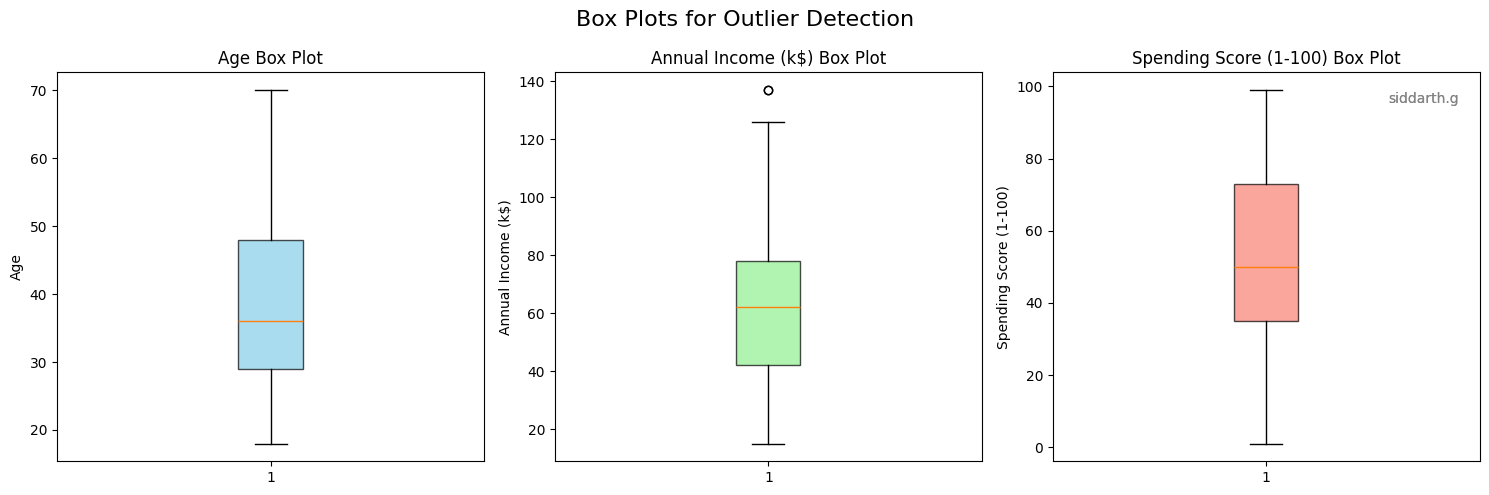

Data shape after preprocessing: (200, 3)
First few rows of preprocessed data:
[[-1.42602061 -1.76824502 -0.44100336]
 [-1.28087856  0.04435075  1.19234243]
 [-1.35344959 -1.72967915 -1.72434649]
 [-1.13573652 -1.72967915  1.03678569]
 [-0.55516833 -1.69111328 -0.40211418]]


In [163]:
# Load and preprocess data
print("\n1. LOADING AND PREPROCESSING DATA")
print_separator()
df = pd.read_csv('data/Q2_Clustering_dataset.csv')
df = load_and_preprocess_data(df, seed)

# Z-scale normalize the columns and one-hot encode categorical variables
feature_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_raw = df[feature_columns].values

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Append one-hot encoded columns for 'Genre'
# encoder = OneHotEncoder()
# X_genre = encoder.fit_transform(df[['Genre']])
# X = np.hstack((X_genre.toarray(), X))

print(f"Data shape after preprocessing: {X.shape}")
print("First few rows of preprocessed data:")
print(X[:5])


2. DETERMINING OPTIMAL NUMBER OF CLUSTERS



2.1 Combined BIC and Silhouette Method:
Computing BIC and Silhouette scores using Custom GMM implementation...
This combined approach trains each model only once per k value.

  k=1... Converged after 2 iterations
BIC: 1726.93, Silhouette: N/A (k=1)
  k=2... Converged after 29 iterations
BIC: 1664.24, Silhouette: 0.0398
  k=3... Converged after 27 iterations
BIC: 1649.93, Silhouette: 0.2498
  k=4... 

Converged after 72 iterations
BIC: 1629.72, Silhouette: 0.3564
  k=5... Converged after 43 iterations
BIC: 1610.73, Silhouette: 0.3089
  k=6... Converged after 75 iterations
BIC: 1659.82, Silhouette: 0.1988
  k=7... BIC: 1666.23, Silhouette: 0.2201
  k=8... BIC: 1701.18, Silhouette: 0.2169
  k=9... Converged after 76 iterations
BIC: 1739.07, Silhouette: 0.1860
  k=10... Converged after 63 iterations
BIC: 1757.52, Silhouette: 0.1192
  k=11... Converged after 53 iterations
BIC: 1802.27, Silhouette: 0.1196
  k=12... Converged after 88 iterations
BIC: 1816.99, Silhouette: 0.1152
  k=13... Converged after 72 iterations
BIC: 1866.83, Silhouette: 0.2036
  k=14... BIC: 1884.56, Silhouette: 0.1749
  k=15... BIC: 1859.13, Silhouette: 0.1071
  k=16... BIC: 1875.67, Silhouette: 0.1454
  k=17... Converged after 88 iterations
BIC: 1886.67, Silhouette: 0.1529
  k=18... BIC: 1937.75, Silhouette: 0.1283
  k=19... Converged after 61 iterations
BIC: 2003.26, Silhouette: 0.1212
  k=20... Converged after 6

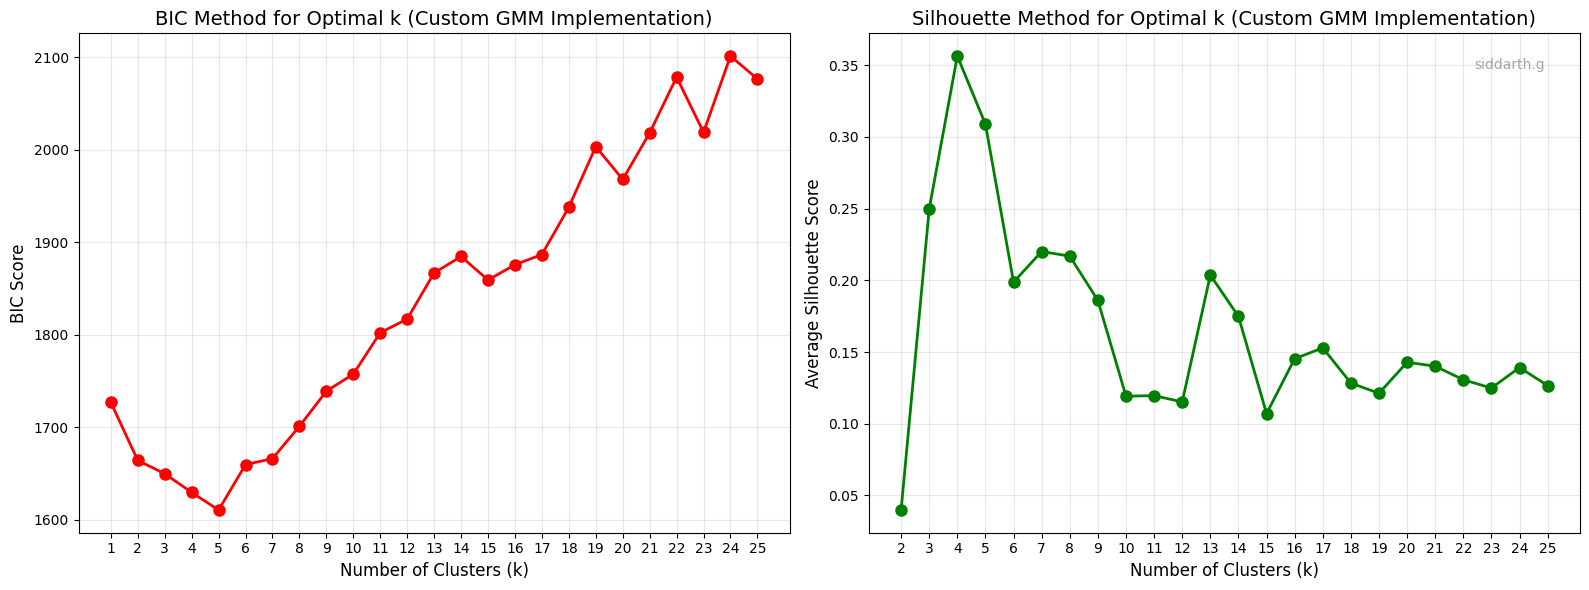


Combined Method Results:
BIC values: {1: '1726.93', 2: '1664.24', 3: '1649.93', 4: '1629.72', 5: '1610.73', 6: '1659.82', 7: '1666.23', 8: '1701.18', 9: '1739.07', 10: '1757.52', 11: '1802.27', 12: '1816.99', 13: '1866.83', 14: '1884.56', 15: '1859.13', 16: '1875.67', 17: '1886.67', 18: '1937.75', 19: '2003.26', 20: '1967.70', 21: '2018.00', 22: '2078.26', 23: '2018.66', 24: '2101.05', 25: '2076.21'}
Silhouette scores: {2: '0.0398', 3: '0.2498', 4: '0.3564', 5: '0.3089', 6: '0.1988', 7: '0.2201', 8: '0.2169', 9: '0.1860', 10: '0.1192', 11: '0.1196', 12: '0.1152', 13: '0.2036', 14: '0.1749', 15: '0.1071', 16: '0.1454', 17: '0.1529', 18: '0.1283', 19: '0.1212', 20: '0.1429', 21: '0.1401', 22: '0.1307', 23: '0.1249', 24: '0.1392', 25: '0.1266'}
Optimal k (minimum BIC): 5
Minimum BIC score: 1610.7295
Optimal k (maximum silhouette score): 4
Maximum silhouette score: 0.3564
Using Custom GMM implementation

*** CHOSEN OPTIMAL K: 5 (based on BIC method) ***


In [164]:
# Determine optimal number of clusters
print("\n2. DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print_separator()

# Combined BIC and Silhouette Method (trains each model only once)
print("\n2.1 Combined BIC and Silhouette Method:")
bic_values, silhouette_scores, bic_k, silhouette_k = combined_optimal_k_method_gmm(X, max_k=25, max_iters=100, use_custom=global_flag)

# Also run individual methods for comparison (keeping original results and plots)
# print("\n2.2 Individual BIC Method (for comparison):")
# bic_values_individual, bic_k_individual = bic_method(X, max_k=25, max_iters=100, use_custom=global_flag)

# print("\n2.3 Individual Silhouette Method (for comparison):")
# silhouette_scores_individual, silhouette_k_individual = silhouette_method_gmm(X, max_k=25, max_iters=100, use_custom=global_flag)

# Choose optimal k (let's use BIC method result as it's more appropriate for GMM)
optimal_k = bic_k
print(f"\n*** CHOSEN OPTIMAL K: {optimal_k} (based on BIC method) ***")


3. FITTING GMM WITH k=5


Using Custom GMM Implementation
Converged after 43 iterations


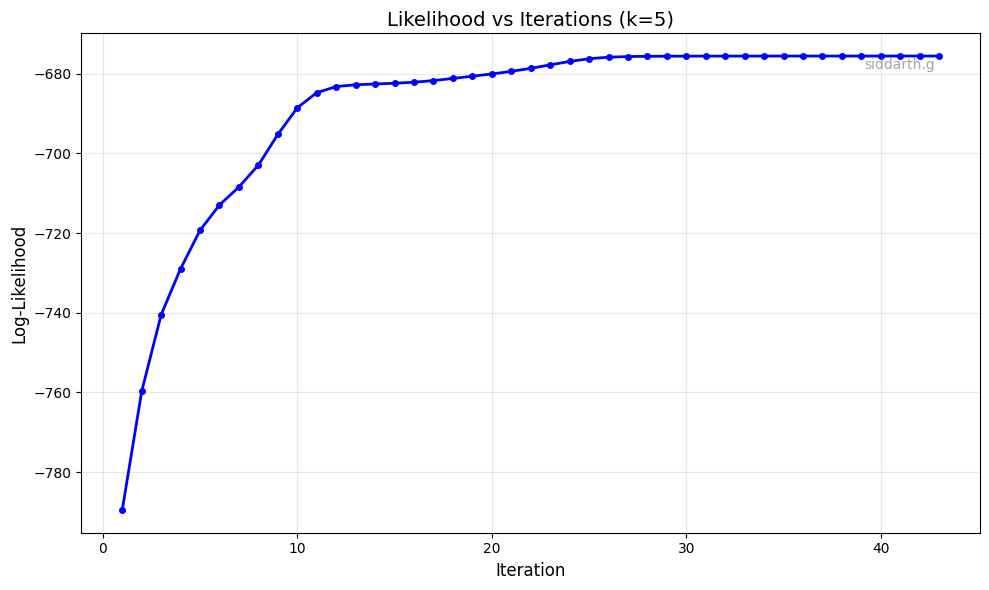

Final log likelihood: -675.5560
Converged in 43 iterations

Final Model Performance:
  Log-likelihood: -675.5560
  BIC Score: 1610.7295
  Membership matrix shape: (200, 5)
  Sample membership probabilities (first 5 samples):
    Sample 1: [0. 0. 1. 0. 0.]
    Sample 2: [0.139 0.303 0.558 0.    0.   ]
    Sample 3: [0.    0.    0.999 0.001 0.   ]
    Sample 4: [0. 1. 0. 0. 0.]
    Sample 5: [0.    0.001 0.999 0.    0.   ]


In [165]:
# Fit final GMM model with optimal k
print(f"\n3. FITTING GMM WITH k={optimal_k}")
print_separator()

if global_flag:
    # Use custom GMM implementation
    print("Using Custom GMM Implementation")
    final_gmm = GMM(k=optimal_k, max_iters=1000)
    final_gmm.fit(X)
    
    # Display convergence information
    final_gmm.drawLikelihood()
    
    final_likelihood = final_gmm.getLogLikelihood()
    final_bic = final_gmm.getBIC()
    
    print(f"\nFinal Model Performance:")
    print(f"  Log-likelihood: {final_likelihood:.4f}")
    print(f"  BIC Score: {final_bic:.4f}")
    
    # Get membership probabilities
    memberships = final_gmm.getMembership()
    print(f"  Membership matrix shape: {memberships.shape}")
    print(f"  Sample membership probabilities (first 5 samples):")
    for i in range(min(5, len(memberships))):
        print(f"    Sample {i+1}: {memberships[i].round(3)}")
        
else:
    # Use sklearn's GaussianMixture
    print("Using Sklearn GaussianMixture Implementation")
    final_gmm = GaussianMixture(n_components=optimal_k, random_state=42, max_iter=1000)
    final_gmm.fit(X)
    
    final_likelihood = final_gmm.score(X) * len(X)  # Convert per-sample to total log-likelihood
    final_bic = final_gmm.bic(X)
    
    print(f"\nFinal Model Performance:")
    print(f"  Log-likelihood: {final_likelihood:.4f}")
    print(f"  BIC Score: {final_bic:.4f}")
    print(f"  Converged: {final_gmm.converged_}")
    print(f"  Number of iterations: {final_gmm.n_iter_}")
    
    # Get membership probabilities
    memberships = final_gmm.predict_proba(X)
    print(f"  Membership matrix shape: {memberships.shape}")
    print(f"  Sample membership probabilities (first 5 samples):")
    for i in range(min(5, len(memberships))):
        print(f"    Sample {i+1}: {memberships[i].round(3)}")


4. VISUALIZATION




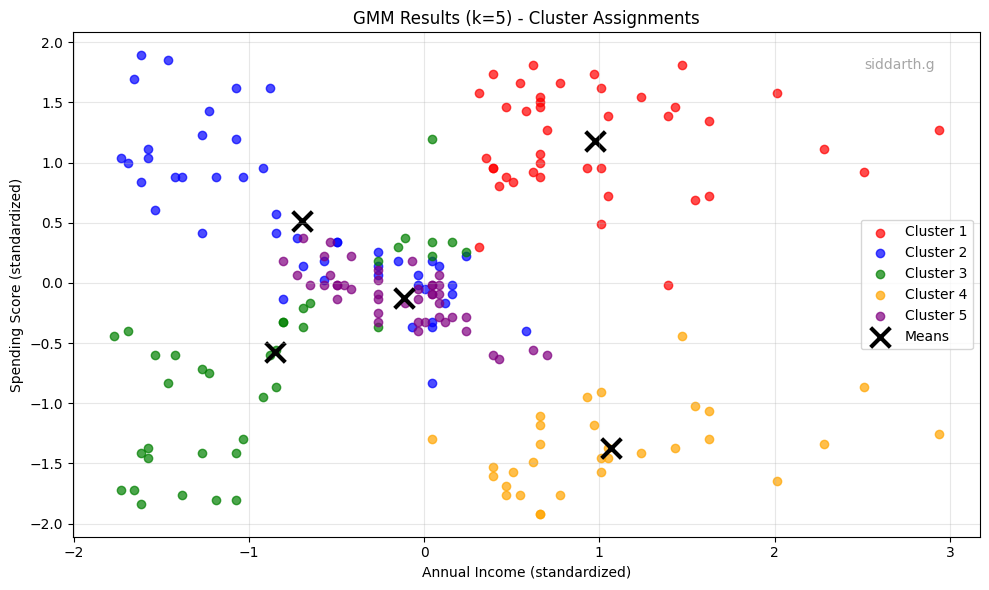

In [166]:
# Visualization
print(f"\n4. VISUALIZATION")
print_separator()
visualize_gmm_clusters(X, final_gmm, f"GMM Results (k={optimal_k})", use_custom=global_flag)